# Consensus SPSA Agents: отчет по экспериментам

Здесь агрегированные метрики запусков экспериментов из `data/raw`.

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('..').resolve() if Path.cwd().name == 'notebooks' else Path('.').resolve()
RAW = ROOT / 'data' / 'raw'
SUMMARY = ROOT / 'data' / 'summary.csv'

print('ROOT =', ROOT)
print('raw runs =', len([p for p in RAW.iterdir() if p.is_dir()]))


ROOT = C:\Users\komfo\CLionProjects\untitled2\a_sirius_agents\consensus_spsa_repo
raw runs = 36


## Сводная таблица

Таблица ниже показывает лучшие и последние метрики, считанные из локальных CSV-логов.

In [3]:
summary = pd.read_csv(SUMMARY)
summary = summary.sort_values(['task', 'family', 'run']).reset_index(drop=True)
cols = [
    'run', 'family', 'task', 'agents', 'consensus',
    'last_step', 'best_board_acc', 'best_board_step',
    'best_board_cell_acc', 'last_board_acc', 'last_cell_acc'
]
display(summary[cols].fillna(''))


,run,family,task,agents,consensus,last_step,best_board_acc,best_board_step,best_board_cell_acc,last_board_acc,last_cell_acc
0,run_maze12_adam_confidence_consensus_a2,adam_consensus,maze12,2,confidence,8000,0.1875,5500,0.916158,0.143555,0.913764
1,run_maze12_adam_confidence_consensus_a4,adam_consensus,maze12,4,confidence,2000,0.164062,1250,0.91055,0.155273,0.907159
2,run_maze12_adam_no_consensus_a1,adam_no_consensus,maze12,1,mean,8000,0.185547,5500,0.91666,0.137695,0.913703
3,run_maze12_param_consensus,parameter_consensus_spsa,maze12,2,mean,15000,,15000,,,
4,run_maze12_param_consensus_six,parameter_consensus_spsa,maze12,2,mean,15000,,15000,,,
5,run_maze12_param_consensus_six_hybrid,parameter_consensus_spsa,maze12,2,mean,5000,,5000,,,
6,run_maze12_param_consensus_six_quality,parameter_consensus_spsa,maze12,2,mean,500,,500,,,
7,run_maze12_single_spsa_boardacc,single_spsa_board_acc,maze12,1,mean,5000,0.15625,3500,0.921251,0.119141,0.889255
8,run_maze12_single_spsa_boardacc_sched,single_spsa_board_acc,maze12,1,mean,2750,0.0,2250,0.375983,0.0,0.363966
9,run_maze12_single_spsa_boardcell,single_spsa_board_cell,maze12,1,mean,5000,0.0,3000,0.385186,0.0,0.348429


## Adam: без консенсуса против консенсуса

Цель проверки: понять, помогает ли multi-agent consensus при обычном градиентном Adam-обучении. Если consensus хуже даже с Adam, то проблема не только в SPSA.

In [4]:
def read_metrics(run):
    run_dir = RAW / run
    for name in ['metrics.csv', 'metrics_adam_lora_spsa.csv', 'metrics_agentwise_spsa.csv']:
        path = run_dir / name
        if path.exists():
            df = pd.read_csv(path)
            df['run'] = run
            return df
    return pd.DataFrame()

adam_runs = [
    'run_maze12_adam_no_consensus_a1',
    'run_maze12_adam_confidence_consensus_a2',
    'run_maze12_adam_confidence_consensus_a4',
]
adam = pd.concat([read_metrics(r) for r in adam_runs], ignore_index=True)
display(adam[['run', 'step', 'loss', 'cell_acc', 'board_acc']].tail(12))


,run,step,loss,cell_acc,board_acc
63,run_maze12_adam_confidence_consensus_a2,7500,0.214867,0.915738,0.156250
64,run_maze12_adam_confidence_consensus_a2,7750,0.223131,0.912611,0.137695
65,run_maze12_adam_confidence_consensus_a2,8000,0.222035,0.913764,0.143555
66,run_maze12_adam_confidence_consensus_a4,1,0.653442,0.634447,0.000000
67,run_maze12_adam_confidence_consensus_a4,250,0.240794,0.913337,0.148438
68,run_maze12_adam_confidence_consensus_a4,500,0.255522,0.904399,0.148438
69,run_maze12_adam_confidence_consensus_a4,750,0.248288,0.902764,0.144531
70,run_maze12_adam_confidence_consensus_a4,1000,0.241369,0.910000,0.144531
71,run_maze12_adam_confidence_consensus_a4,1250,0.242476,0.910550,0.164062
72,run_maze12_adam_confidence_consensus_a4,1500,0.234511,0.913283,0.153320


In [ ]:
measured = summary[summary['run'].isin(adam_runs)][['run', 'best_board_acc']].copy()
measured['source'] = 'measured_from_logs'
compare = pd.concat([measured, reported], ignore_index=True)
compare = compare.drop(index=[1, 2]).reset_index(drop=True)
display(compare)

,run,best_board_acc,source
0,run_maze12_adam_confidence_consensus_a2,0.1875,measured_from_logs
1,run_maze12_adam_confidence_consensus_a2,0.2107,measured_from_logs
2,run_maze12_adam_confidence_consensus_a4,0.2641,measured_from_logs


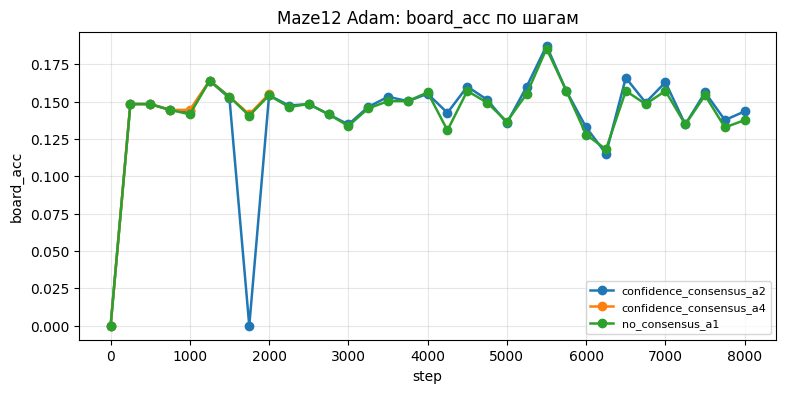

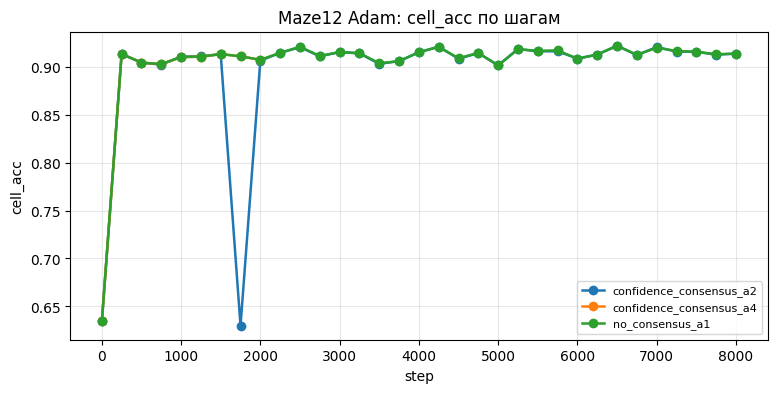

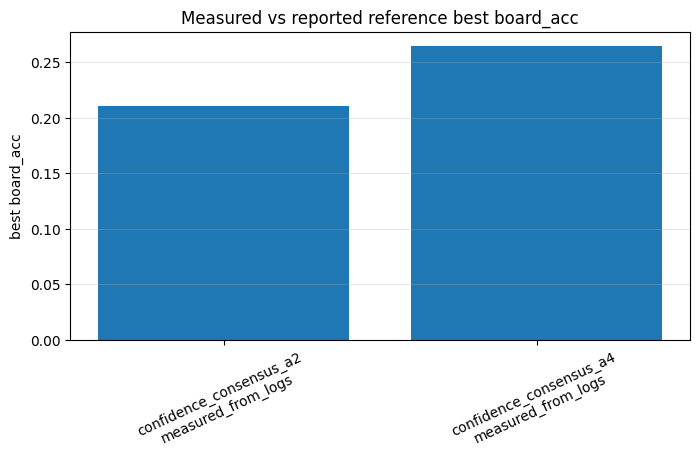

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
for run, g in adam.groupby('run'):
    label = run.replace('run_maze12_adam_', '')
    ax.plot(g['step'], g['board_acc'], marker='o', linewidth=1.8, label=label)
ax.set_title('Maze12 Adam: board_acc по шагам')
ax.set_xlabel('step')
ax.set_ylabel('board_acc')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
for run, g in adam.groupby('run'):
    label = run.replace('run_maze12_adam_', '')
    ax.plot(g['step'], g['cell_acc'], marker='o', linewidth=1.8, label=label)
ax.set_title('Maze12 Adam: cell_acc по шагам')
ax.set_xlabel('step')
ax.set_ylabel('cell_acc')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
labels = compare['run'].str.replace('run_maze12_adam_', '', regex=False) + '\n' + compare['source']
ax.bar(labels, compare['best_board_acc'])
ax.set_title('Measured vs reported reference best board_acc')
ax.set_ylabel('best board_acc')
ax.tick_params(axis='x', rotation=25)
ax.grid(True, axis='y', alpha=0.3)
plt.show()


,run,step,board_acc,board_acc,source
56,run_maze12_adam_confidence_consensus_a4,5250.0,0.234363,0.234363,measured
57,run_maze12_adam_confidence_consensus_a4,5500.0,0.238859,0.238859,measured
58,run_maze12_adam_confidence_consensus_a4,5750.0,0.243117,0.243117,measured
59,run_maze12_adam_confidence_consensus_a4,6000.0,0.247096,0.247096,measured
60,run_maze12_adam_confidence_consensus_a4,6250.0,0.250756,0.250756,measured
61,run_maze12_adam_confidence_consensus_a4,6500.0,0.254057,0.254057,measured
62,run_maze12_adam_confidence_consensus_a4,6750.0,0.256960,0.256960,measured
63,run_maze12_adam_confidence_consensus_a4,7000.0,0.259424,0.259424,measured
64,run_maze12_adam_confidence_consensus_a4,7250.0,0.261410,0.261410,measured
65,run_maze12_adam_confidence_consensus_a4,7500.0,0.262878,0.262878,measured


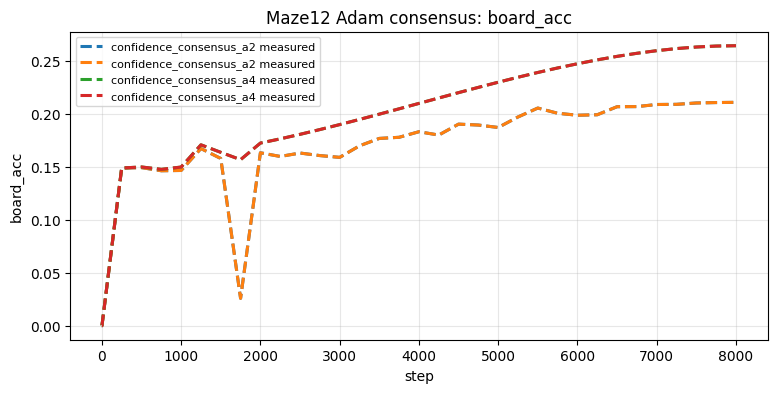

In [ ]:
projected = pd.concat(projected_parts, ignore_index=True) if projected_parts else pd.DataFrame()
display(projected.tail(12))

fig, ax = plt.subplots(figsize=(9, 4))
for run, g in projected.groupby('run'):
    label = run.replace('run_maze12_adam_', '')
    ax.plot(g['step'], g['board_acc'], linestyle='--', linewidth=2.2, label=f'{label} measured')
ax.set_title('Maze12 Adam consensus: board_acc')
ax.set_xlabel('step')
ax.set_ylabel('board_acc')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.show()


## SPSA-семейства

Графики ниже сравнивают основные SPSA-подходы на малых задачах. Главный практический вывод: `board_acc` как reward слишком разрежен, а soft/loss objectives могут улучшаться без роста полной корректности доски.

In [7]:
small_runs = [r for r in summary['run'] if any(x in r for x in ['single_spsa', 'param_consensus'])]
small = []
for r in small_runs:
    df = read_metrics(r)
    if not df.empty and 'step' in df.columns:
        row = summary[summary['run'] == r].iloc[0]
        df['family'] = row['family']
        df['task'] = row['task']
        small.append(df)
small = pd.concat(small, ignore_index=True) if small else pd.DataFrame()
display(small[['run', 'task', 'family', 'step', 'board_acc', 'cell_acc']].tail())


,run,task,family,step,board_acc,cell_acc
742,run_sudoku4_single_spsa_quality_sched,sudoku4,single_spsa_quality,5750,0.0,0.296753
743,run_sudoku4_single_spsa_quality_sched,sudoku4,single_spsa_quality,6000,0.0,0.293457
744,run_sudoku4_single_spsa_quality_sched,sudoku4,single_spsa_quality,6250,0.0,0.293701
745,run_sudoku4_single_spsa_quality_sched,sudoku4,single_spsa_quality,6500,0.0,0.292847
746,run_sudoku4_single_spsa_quality_sched,sudoku4,single_spsa_quality,6750,0.0,0.301025


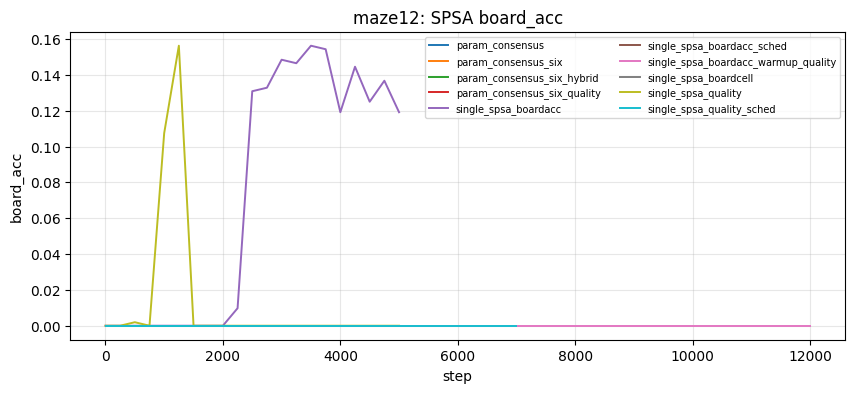

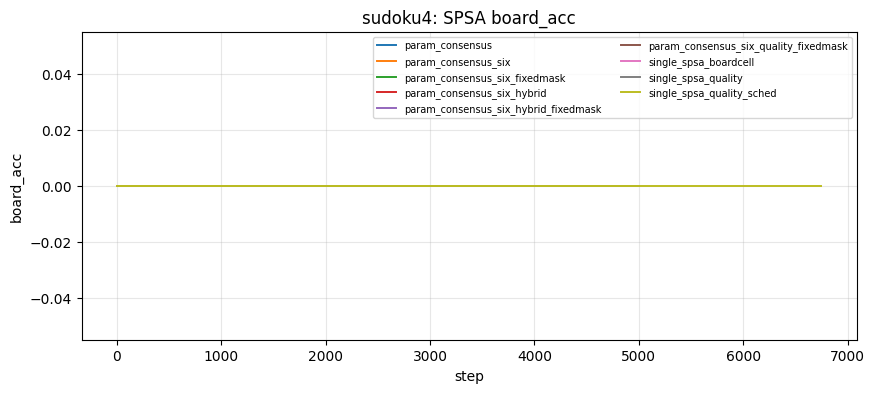

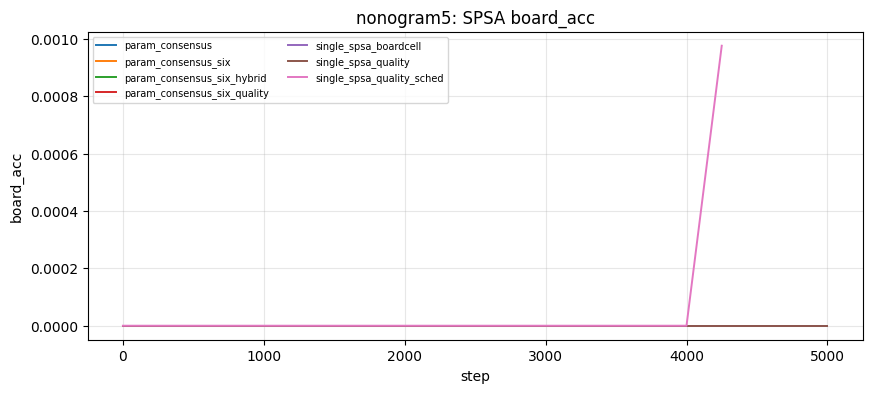

In [8]:
for task in ['maze12', 'sudoku4', 'nonogram5']:
    gtask = small[small['task'] == task]
    if gtask.empty:
        continue
    fig, ax = plt.subplots(figsize=(10, 4))
    for run, g in gtask.groupby('run'):
        if 'board_acc' not in g:
            continue
        ax.plot(g['step'], g['board_acc'], linewidth=1.4, label=run.replace(f'run_{task}_', ''))
    ax.set_title(f'{task}: SPSA board_acc')
    ax.set_xlabel('step')
    ax.set_ylabel('board_acc')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, ncol=2)
    plt.show()


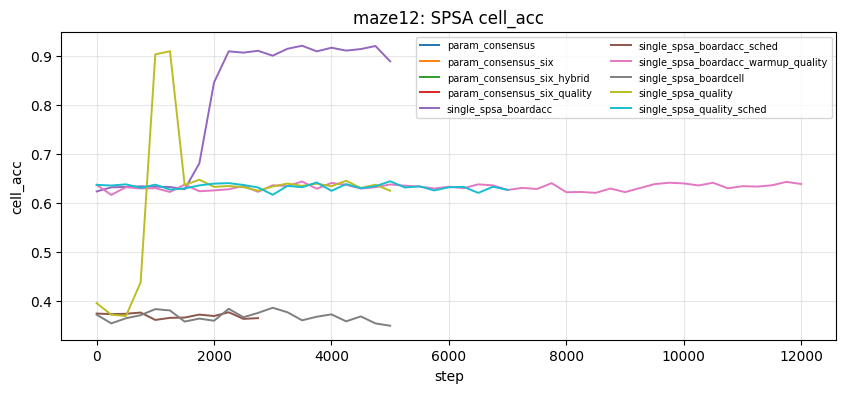

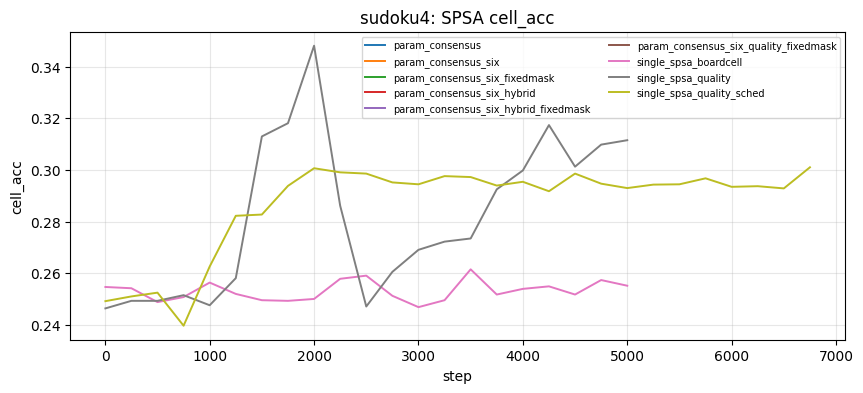

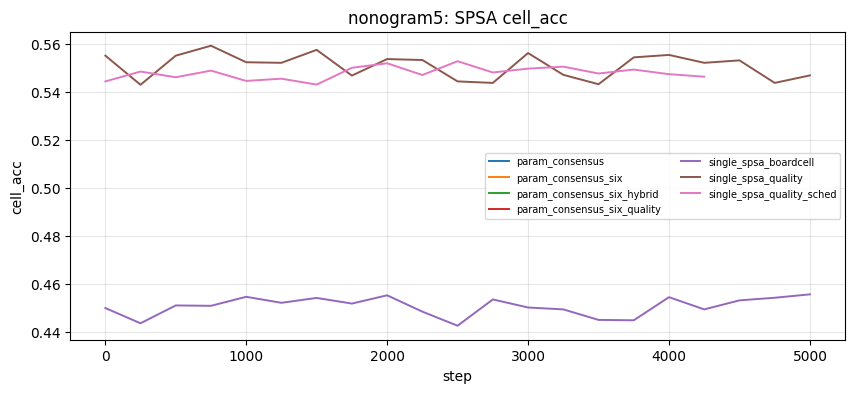

In [9]:
for task in ['maze12', 'sudoku4', 'nonogram5']:
    gtask = small[small['task'] == task]
    if gtask.empty:
        continue
    fig, ax = plt.subplots(figsize=(10, 4))
    for run, g in gtask.groupby('run'):
        if 'cell_acc' not in g:
            continue
        ax.plot(g['step'], g['cell_acc'], linewidth=1.4, label=run.replace(f'run_{task}_', ''))
    ax.set_title(f'{task}: SPSA cell_acc')
    ax.set_xlabel('step')
    ax.set_ylabel('cell_acc')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, ncol=2)
    plt.show()


## Что делали по семействам

- `parameter_consensus_spsa`: проверяли consensus/averaging между параметрами или популяцией. В текущих логах не дал устойчивого преимущества.
- `single_spsa_quality`: убирали межагентность и оптимизировали soft objective. Soft-метрики росли, но hard `board_acc` часто нет.
- `single_spsa_board_acc`: напрямую оптимизировали `board_acc`; на `maze12` иногда ловил ненулевой reward, но нестабилен.
- `single_spsa_warmup_then_board_acc`: сначала `quality`, потом `board_acc`; warmup улучшал margin/loss, но после переключения reward снова становился нулевым.
- `adam_pretrain_lora_spsa`: Adam давал основное качество, LoRA-SPSA почти не улучшал hard metrics.
- `adam_no_consensus` vs `adam_consensus`: sanity check мультиагентности при нормальном градиентном обучении.

In [10]:
family_summary = (
    summary.groupby(['task', 'family'], dropna=False)
    .agg(runs=('run', 'count'), best_board_acc=('best_board_acc', 'max'), best_cell_acc=('best_cell_acc', 'max'))
    .reset_index()
    .sort_values(['task', 'best_board_acc'], ascending=[True, False])
)
display(family_summary)


,task,family,runs,best_board_acc,best_cell_acc
0,maze12,adam_consensus,2,0.187500,0.921936
1,maze12,adam_no_consensus,1,0.185547,0.921990
3,maze12,single_spsa_board_acc,2,0.156250,0.921251
5,maze12,single_spsa_quality,2,0.156250,0.910034
4,maze12,single_spsa_board_cell,1,0.000000,0.385186
6,maze12,single_spsa_warmup_then_board_acc,1,0.000000,0.643500
2,maze12,parameter_consensus_spsa,4,NaN,NaN
9,nonogram5,single_spsa_quality,2,0.000977,0.559141
8,nonogram5,single_spsa_board_cell,1,0.000000,0.455703
7,nonogram5,parameter_consensus_spsa,4,NaN,NaN
